# Optimisation raisonnée avec Optuna — XGBoost sur `gold_dataset` (horizon 24h)

Ce notebook construit une démarche d'optimisation d'hyperparamètres **raisonnée**, pas une recherche aveugle sur un grand espace :

1. Cadrage (modèle, horizon, métrique, protocole de validation) + baseline de référence.
2. Espace de recherche borné et plausible pour XGBoost.
3. Fonction objectif : PR-AUC moyenne en validation croisée temporelle.
4. Étude Optuna (TPE + pruning + budget borné, seed fixée pour la reproductibilité).
5. Analyse post-optimisation (historique, importance des HP, stabilité, risque de sur-ajustement du tuning).
6. Validation finale sur le test set (jamais vu pendant le tuning), comparée à la baseline.

Tout est suivi dans MLflow (mêmes conventions que le reste du projet : SQLite locale, `mlflow/mlflow.db`).

In [1]:
import time
_notebook_start_time = time.time()

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import optuna.visualization.matplotlib as ovm

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score, roc_auc_score

import mlflow

SEED = 42
np.random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1. Cadrage : modèle, horizon, métrique, protocole — et baseline de référence

**Choix figés avant tout tuning** (pour ne pas mélanger "quel problème résoudre" et "comment l'optimiser") :

- **Modèle** : XGBoost (`XGBClassifier`).
- **Horizon** : `label_failure_next_24h` — compromis rappel/anticipation déjà identifié dans les travaux précédents sur ce dataset.
- **Métrique** : **PR-AUC** (`average_precision_score`), pas l'accuracy — cohérent avec le déséquilibre de classe du dataset (~17 % de positifs sur cet horizon).
- **Protocole de validation** : `TimeSeriesSplit` sur le train (respect de l'ordre temporel — pas de fuite, une observation future ne doit jamais informer une prédiction passée).
- **Features** : mêmes exclusions que le reste du projet (identifiants, colonnes de fuite temporelle, labels des autres horizons).

In [2]:
GOLD_PATH = "artifacts/ingestions/datas/gold_dataset.parquet"  # <- chemin relatif à la racine du projet ; adapter si le notebook est lancé d'ailleurs

EXCLUDE_BASE = [
    'machine_id_std', 'window_start', 'window_end',
    'future_incident_count_6h', 'label_failure_next_6h',
    'future_incident_count_12h', 'label_failure_next_12h',
    'future_incident_count_24h', 'label_failure_next_24h',
    'future_incident_count_48h', 'label_failure_next_48h',
    'incident_count_1h', 'incident_max_severity_1h',
    'incident_count_prev_24h', 'incident_max_severity_prev_24h',
    'incident_count_prev_7d', 'hours_since_last_incident',
    'type_surchauffe_count_prev_24h', 'type_baisse_pression_count_prev_24h',
    'type_vibration_count_prev_24h', 'type_bruit_mecanique_count_prev_24h',
    'type_surconsommation_count_prev_24h', 'type_blocage_mecanique_count_prev_24h',
    'type_alarme_capteur_count_prev_24h', 'type_arret_urgence_count_prev_24h',
    'type_defaut_qualite_count_prev_24h',
    'days_since_last_maintenance', 'maintenance_count_prev_30d',
    'split_set',
]
HORIZON = 'label_failure_next_24h'
ALL_HORIZONS = ['label_failure_next_6h', 'label_failure_next_12h', 'label_failure_next_24h', 'label_failure_next_48h']

# --- Optimisation temps de traitement (1/5) : parallélisme CPU ---
# Deux usages différents du CPU, avec des réglages différents :
#   - Entraînements isolés (baseline, modèle final) : un seul modèle à la fois -> lui donner tous les cœurs.
#   - Pendant la recherche Optuna (étape 5) : on préfère paralléliser les ESSAIS plutôt que les threads
#     internes de XGBoost (un XGBoost multi-thread sur un modèle qui s'entraîne déjà en quelques secondes
#     a plus d'overhead de synchronisation que de gain réel ; lancer plusieurs essais indépendants en
#     parallèle passe mieux à l'échelle). D'où XGB_N_JOBS_SEARCH=1 et OPTUNA_N_JOBS=N_CORES.
N_CORES = os.cpu_count() or 1
XGB_N_JOBS_SINGLE = N_CORES   # pour la baseline et le modèle final (un seul entraînement à la fois)
XGB_N_JOBS_SEARCH = 1         # pour chaque essai Optuna (la parallélisation se fait au niveau des essais)
OPTUNA_N_JOBS = 1              # défaut prudent — voir note détaillée étape 5 avant d'augmenter

print(f"Cœurs détectés : {N_CORES}")

df = pd.read_parquet(GOLD_PATH)
feats = [c for c in df.columns if c not in EXCLUDE_BASE and c not in ALL_HORIZONS]

train_df = df[df.split_set == 'train'].sort_values('window_start').reset_index(drop=True)
val_df = df[df.split_set == 'validation']
test_df = df[df.split_set == 'test']

X_train, y_train = train_df[feats], train_df[HORIZON].astype(int)
X_val, y_val = val_df[feats], val_df[HORIZON].astype(int)
X_test, y_test = test_df[feats], test_df[HORIZON].astype(int)

print(f"Features : {len(feats)}")
print(f"Train : {len(X_train)}  ({y_train.mean():.1%} positifs)")
print(f"Validation : {len(X_val)}  ({y_val.mean():.1%} positifs)")
print(f"Test : {len(X_test)}  ({y_test.mean():.1%} positifs)")

Cœurs détectés : 4
Features : 71
Train : 93990  (16.6% positifs)
Validation : 20145  (17.2% positifs)
Test : 20145  (17.3% positifs)


### Modèle baseline (hyperparamètres par défaut raisonnables, sans tuning)

Un XGBoost avec des valeurs par défaut communément admises — sert de **point de comparaison** pour juger si le tuning Optuna apporte un gain réel, pas juste un chiffre plus élevé sur un run isolé.

In [3]:
MLFLOW_TRACKING_URI = "sqlite:///mlflow/mlflow.db"  # <- cohérent avec le reste du projet
EXPERIMENT_NAME = "xgboost_optuna_predictive_maintenance"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

BASELINE_PARAMS = dict(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9, min_child_weight=1,
    reg_lambda=1.0, reg_alpha=0.0,
)

with mlflow.start_run(run_name="baseline_xgboost_default") as run_baseline:
    mlflow.log_params({**BASELINE_PARAMS, "horizon": HORIZON, "model": "xgboost_baseline"})

    baseline_model = xgb.XGBClassifier(
        **BASELINE_PARAMS, tree_method="hist", n_jobs=XGB_N_JOBS_SINGLE, eval_metric="aucpr", random_state=SEED,
    )
    baseline_model.fit(X_train, y_train)

    val_proba_baseline = baseline_model.predict_proba(X_val)[:, 1]
    baseline_prauc = average_precision_score(y_val, val_proba_baseline)
    baseline_auc = roc_auc_score(y_val, val_proba_baseline)

    mlflow.log_metrics({"prauc_val": baseline_prauc, "auc_val": baseline_auc})
    run_id_baseline = run_baseline.info.run_id

print(f"Baseline — PR-AUC (val) = {baseline_prauc:.4f}   AUC (val) = {baseline_auc:.4f}")

Baseline — PR-AUC (val) = 0.4409   AUC (val) = 0.6894


### Rendu — tableau de référence

In [4]:
reference_table = pd.DataFrame([
    {"modèle": "baseline (défauts raisonnables)", "PR-AUC (val)": baseline_prauc, "AUC (val)": baseline_auc},
])
reference_table

,modèle,PR-AUC (val),AUC (val)
0,baseline (défauts raisonnables),0.440885,0.689389


## 2-3. Espace de recherche, sampler et pruner — rappel des choix

- **Sampler** : `TPESampler` — bon compromis exploration/exploitation pour un espace de taille moyenne (9 hyperparamètres).
- **Pruner** : `MedianPruner` — arrête un essai si sa performance intermédiaire est sous la médiane des essais précédents au même stade, évite de gaspiller du calcul sur des combinaisons manifestement mauvaises.
- **Pruning appliqué au niveau des folds de validation croisée** (pas au niveau de chaque itération de boosting individuelle) : après chaque fold, on rapporte la PR-AUC moyenne courante à Optuna, qui décide de continuer ou d'arrêter l'essai avant le fold suivant. Ce choix est délibéré — le callback officiel `XGBoostPruningCallback`, qui rapporte à chaque itération de boosting, entre en conflit avec une validation croisée à plusieurs folds (chaque fold repart de l'itération 0, ce qui perturbe le suivi des étapes côté Optuna). Le pruning par fold reste correctement piloté par la progression réelle de l'entraînement XGBoost (chaque fold reflète un entraînement complet avec son propre early stopping interne), tout en restant robuste.

## 4. Espace de recherche borné pour XGBoost

Bornes choisies en fonction du contexte (134k lignes, ~71 features, fort déséquilibre de classe), pas des plages génériques.

In [5]:
SEARCH_SPACE_INFO = {
    "n_estimators":     "100 – 300   (borné haut par l'early stopping interne à chaque fold — resserré à 300 pour le temps de calcul, cf. optimisations étape 5)",
    "max_depth":        "3 – 8       (au-delà de 8, sur-apprentissage quasi systématique sur ce volume de données)",
    "learning_rate":    "0.01 – 0.3  (log-scale — un ordre de grandeur en dessous/au-dessus de la valeur usuelle 0.1)",
    "subsample":        "0.6 – 1.0   (sous 0.6, trop de variance ; 1.0 = pas de sous-échantillonnage)",
    "colsample_bytree": "0.6 – 1.0   (idem, par colonne plutôt que par ligne)",
    "min_child_weight": "1 – 10      (régularise la taille minimale des feuilles, évite les splits sur du bruit)",
    "reg_lambda":       "1e-3 – 10   (log-scale — L2, de quasi rien à une régularisation forte)",
    "reg_alpha":        "1e-3 – 10   (log-scale — L1, idem)",
    "scale_pos_weight": "1 – ratio négatifs/positifs (borne haute = rééquilibrage complet du déséquilibre observé)",
}
for hp, desc in SEARCH_SPACE_INFO.items():
    print(f"{hp:<18} : {desc}")

n_estimators       : 100 – 300   (borné haut par l'early stopping interne à chaque fold — resserré à 300 pour le temps de calcul, cf. optimisations étape 5)
max_depth          : 3 – 8       (au-delà de 8, sur-apprentissage quasi systématique sur ce volume de données)
learning_rate      : 0.01 – 0.3  (log-scale — un ordre de grandeur en dessous/au-dessus de la valeur usuelle 0.1)
subsample          : 0.6 – 1.0   (sous 0.6, trop de variance ; 1.0 = pas de sous-échantillonnage)
colsample_bytree   : 0.6 – 1.0   (idem, par colonne plutôt que par ligne)
min_child_weight   : 1 – 10      (régularise la taille minimale des feuilles, évite les splits sur du bruit)
reg_lambda         : 1e-3 – 10   (log-scale — L2, de quasi rien à une régularisation forte)
reg_alpha          : 1e-3 – 10   (log-scale — L1, idem)
scale_pos_weight   : 1 – ratio négatifs/positifs (borne haute = rééquilibrage complet du déséquilibre observé)


### Pourquoi borner plutôt qu'ouvrir grand ?

1. **Un espace non borné n'est pas plus "objectif", juste plus coûteux à explorer** — Optuna (TPE) doit échantillonner suffisamment de points pour construire un modèle de densité fiable ; un espace 10x plus large avec le même budget d'essais donne une exploration 10x plus clairsemée, pas une meilleure garantie de trouver l'optimum.
2. **Les bornes encodent de la connaissance du domaine, pas un biais arbitraire** — ex. `max_depth > 10` sur 71 features et 94k lignes d'entraînement mène quasi systématiquement à du sur-apprentissage (observé en pratique sur ce type de dataset tabulaire), l'inclure dans l'espace ne fait que diluer le budget d'essais sur des zones à éviter.
3. **Un espace trop large complique aussi l'analyse a posteriori** (étape 7) — l'importance des hyperparamètres et les slice plots sont plus lisibles quand chaque hyperparamètre a une plage resserrée autour de valeurs plausibles, plutôt qu'une plage énorme où 95 % des valeurs sont hors de la zone utile.
4. **Le risque inverse existe aussi** : des bornes trop resserrées peuvent exclure la vraie meilleure valeur. D'où le choix de plages qui restent larges d'un facteur ~5-10x autour des valeurs usuelles (ex. `learning_rate` de 0.01 à 0.3, alors que la valeur "par défaut" est 0.1-0.3 selon les implémentations) plutôt que des plages étroites centrées sur une seule hypothèse.

En résumé : borner n'est pas une contrainte qu'on subit, c'est un choix de conception qui rend la recherche plus efficace **et** plus interprétable.

### Fonction objectif : PR-AUC moyenne en validation croisée temporelle

In [6]:
N_SPLITS = 3  # TimeSeriesSplit — nombre de folds (compromis coût de calcul / stabilité de l'estimation)

# --- Optimisation temps de traitement (2/5) : sous-échantillonnage pour la RECHERCHE uniquement ---
# Le classement relatif des hyperparamètres reste généralement stable avec moins de données ;
# seul le modèle FINAL (étape 7) est réentraîné sur l'intégralité de train+validation.
# Sous-échantillonnage systématique (pas aléatoire) pour préserver l'ordre temporel :
# un stride de 2 garde une ligne sur deux, réparties sur toute la période (pas un simple .head()).
SEARCH_SAMPLE_FRACTION = 0.5   # 1.0 = pas de sous-échantillonnage, utiliser le train complet pour la recherche
_stride = max(1, round(1 / SEARCH_SAMPLE_FRACTION))

X_train_arr_full = X_train.values
y_train_arr_full = y_train.values
X_train_arr = X_train_arr_full[::_stride]
y_train_arr = y_train_arr_full[::_stride]

neg_count = (y_train_arr == 0).sum()
pos_count = (y_train_arr == 1).sum()
SCALE_POS_WEIGHT_MAX = neg_count / pos_count

print(f"Échantillon de recherche : {len(X_train_arr)} lignes (stride={_stride}, {SEARCH_SAMPLE_FRACTION:.0%} du train complet)")
print(f"Ratio négatifs/positifs (échantillon recherche) : {SCALE_POS_WEIGHT_MAX:.2f}  -> borne haute de scale_pos_weight")


def objective(trial: optuna.Trial) -> float:
    params = {
        # Optimisation (4/5) : n_estimators borné à 300 (pas 600) — l'early stopping arrête presque
        # toujours l'entraînement bien avant (observé : ~55-70 itérations en pratique sur ce dataset),
        # une borne haute à 600 ne sert quasiment jamais mais alourdit le pire cas si early stopping
        # ne se déclenche pas (ex. avec un learning_rate très faible).
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, SCALE_POS_WEIGHT_MAX),
    }

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_scores = []

    for fold_i, (tr_idx, va_idx) in enumerate(tscv.split(X_train_arr)):
        Xtr, Xva = X_train_arr[tr_idx], X_train_arr[va_idx]
        ytr, yva = y_train_arr[tr_idx], y_train_arr[va_idx]

        model = xgb.XGBClassifier(
            **params, tree_method="hist", n_jobs=XGB_N_JOBS_SEARCH, eval_metric="aucpr",
            early_stopping_rounds=20, random_state=SEED,
        )
        model.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)

        proba = model.predict_proba(Xva)[:, 1]
        fold_scores.append(average_precision_score(yva, proba))

        # Pruning au niveau du fold : Optuna peut arrêter l'essai avant le fold suivant
        trial.report(float(np.mean(fold_scores)), step=fold_i)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))

Échantillon de recherche : 46995 lignes (stride=2, 50% du train complet)
Ratio négatifs/positifs (échantillon recherche) : 5.02  -> borne haute de scale_pos_weight


## 5. Étude Optuna : TPE + pruning + budget borné, seed fixée

**Reproductibilité** : `TPESampler(seed=SEED)` fixe l'échantillonnage des hyperparamètres — deux exécutions avec le même seed proposent la même séquence d'essais (à XGBoost/données identiques par ailleurs).

**Budget borné** : `n_trials` **et** `timeout` — le premier des deux atteints arrête l'étude. Évite qu'un poste de calcul plus lent ou plus rapide ne change silencieusement la portée de la recherche.

**Suivi MLflow par essai** : chaque essai Optuna est loggé comme un run MLflow distinct (params + PR-AUC CV), pour pouvoir comparer visuellement tous les essais dans l'UI MLflow, pas seulement via les objets Optuna en mémoire.
### Optimisation temps de traitement (5/5) : paralléliser les essais (`OPTUNA_N_JOBS`)

`study.optimize(..., n_jobs=OPTUNA_N_JOBS)` peut lancer plusieurs essais en parallèle. **Réglé prudemment à `1` par défaut** ici pour deux raisons :

1. **MLflow + SQLite gère mal les écritures concurrentes** — plusieurs essais en parallèle qui loggent chacun dans `mlflow/mlflow.db` en même temps peuvent provoquer des erreurs `database is locked`. Si tu augmentes `OPTUNA_N_JOBS`, teste d'abord sur quelques essais ; en cas d'erreur de verrou, retire le logging MLflow par essai (garde-le seulement pour le meilleur essai final) ou passe à un backend MLflow plus robuste à la concurrence (serveur MLflow dédié plutôt que fichier SQLite local).
2. **Cohérence avec `XGB_N_JOBS_SEARCH=1`** — la stratégie ici est de paralléliser les essais, pas les threads internes de XGBoost. Sur une machine à N cœurs, mets `OPTUNA_N_JOBS = N_CORES` pour en tirer parti (chaque essai utilise 1 cœur, N essais tournent simultanément).

In [7]:
N_TRIALS = 50
TIMEOUT_SECONDS = 3600  # 1h — budget de secours si N_TRIALS n'est pas atteint dans ce temps

sampler = TPESampler(seed=SEED)
pruner = MedianPruner(n_warmup_steps=1)  # laisse au moins 1 fold avant de pouvoir couper un essai

study = optuna.create_study(
    study_name="xgboost_gold_24h",
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
)


def objective_with_mlflow(trial: optuna.Trial) -> float:
    with mlflow.start_run(run_name=f"optuna_trial_{trial.number}", nested=False):
        score = objective(trial)
        mlflow.log_params(trial.params)
        mlflow.log_metric("prauc_cv", score)
        mlflow.log_param("trial_state", "pruned" if trial.should_prune() else "complete")
        return score


_t_study_start = time.time()
study.optimize(objective_with_mlflow, n_trials=N_TRIALS, timeout=TIMEOUT_SECONDS, n_jobs=OPTUNA_N_JOBS)
_study_elapsed = time.time() - _t_study_start

n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])

print(f"Étude terminée en {_study_elapsed:.1f}s ({_study_elapsed/60:.1f} min)")
print(f"Essais complets : {n_complete}  —  Essais élagués (pruned) : {n_pruned}")
print(f"Meilleur essai : #{study.best_trial.number}  —  PR-AUC (CV) = {study.best_value:.4f}")
print(f"Meilleurs hyperparamètres : {study.best_params}")

Étude terminée en 780.9s (13.0 min)
Essais complets : 25  —  Essais élagués (pruned) : 25
Meilleur essai : #49  —  PR-AUC (CV) = 0.4056
Meilleurs hyperparamètres : {'n_estimators': 274, 'max_depth': 4, 'learning_rate': 0.04721550295972184, 'subsample': 0.8337377980053565, 'colsample_bytree': 0.8350239097947828, 'min_child_weight': 2, 'reg_lambda': 1.990637346057538, 'reg_alpha': 0.029380946086010187, 'scale_pos_weight': 1.3060797197966412}


### Le meilleur essai bat (ou non) la baseline — les deux cas sont instructifs

On évalue le meilleur essai sur la **validation** (même split que la baseline) pour une comparaison directe.

In [8]:
best_model = xgb.XGBClassifier(
    **study.best_params, tree_method="hist", n_jobs=1, eval_metric="aucpr", random_state=SEED,
)
best_model.fit(X_train, y_train)

val_proba_best = best_model.predict_proba(X_val)[:, 1]
best_prauc_val = average_precision_score(y_val, val_proba_best)
best_auc_val = roc_auc_score(y_val, val_proba_best)

with mlflow.start_run(run_name="optuna_best_trial_validation"):
    mlflow.log_params({**study.best_params, "horizon": HORIZON, "model": "xgboost_optuna_best"})
    mlflow.log_metrics({"prauc_val": best_prauc_val, "auc_val": best_auc_val, "prauc_cv": study.best_value})
    run_id_best = mlflow.active_run().info.run_id

gain_prauc = best_prauc_val - baseline_prauc
gain_pct = 100 * gain_prauc / baseline_prauc

reference_table = pd.concat([reference_table, pd.DataFrame([
    {"modèle": f"Optuna best trial (#{study.best_trial.number})", "PR-AUC (val)": best_prauc_val, "AUC (val)": best_auc_val},
])], ignore_index=True)

print(reference_table)
print(f"\nGain PR-AUC (val) vs baseline : {gain_prauc:+.4f}  ({gain_pct:+.1f}%)")

                            modèle  PR-AUC (val)  AUC (val)
0  baseline (défauts raisonnables)      0.440885   0.689389
1          Optuna best trial (#49)      0.458339   0.702096

Gain PR-AUC (val) vs baseline : +0.0175  (+4.0%)


**Lecture — les deux cas de figure sont instructifs :**

- **Si le meilleur essai bat nettement la baseline** : le tuning apporte une vraie valeur sur ce problème — les hyperparamètres par défaut n'étaient pas adaptés à ce dataset précis (volume, déséquilibre, bruit). Vérifier ensuite que le gain se confirme sur le test (étape 8) avant de le croire définitivement.
- **Si le meilleur essai ne bat pas (ou à peine) la baseline** : ce n'est **pas un échec de la méthode** — c'est une information utile en soi : le modèle XGBoost est déjà proche de son plafond de performance sur ce dataset avec des hyperparamètres raisonnables, et les gaps restants viennent probablement d'ailleurs (feature engineering, volume de données, qualité des labels) plutôt que du réglage fin des hyperparamètres. Continuer à chercher un budget d'essais plus grand serait alors un mauvais usage du temps de calcul.

### À partir de quand l'amélioration ne « vaut » plus le calcul dépensé ?

Il n'y a pas de seuil universel, mais quelques repères concrets pour ce genre de projet :

1. **Rendement décroissant visible sur l'historique d'optimisation** (étape 7) : si les 10 derniers essais n'améliorent plus le meilleur score de manière notable, le budget restant a de très fortes chances d'être dépensé pour un gain marginal.
2. **Comparer le gain au bruit de mesure** : si le gain observé (`gain_prauc`) est du même ordre de grandeur que la variance entre folds de CV pour un même essai (cf. étape 7, stabilité), ce n'est probablement pas un vrai gain mais une fluctuation d'échantillonnage.
3. **Mettre en regard le coût réel** : chaque essai ici a coûté environ 3 entraînements XGBoost (un par fold). Sur ce poste (CPU mono-cœur), 50 essais représentent déjà un budget significatif — multiplier ce budget par 10 pour un gain de PR-AUC de +0.005 n'est généralement pas justifiable en contexte production, sauf enjeu métier très spécifique où chaque point de PR-AUC a une valeur monétaire explicite.
4. **Règle pragmatique** : arrêter d'investir du calcul en tuning dès que le gain incrémental par essai supplémentaire devient plus petit que l'incertitude de mesure de la métrique elle-même (écart-type inter-folds) — au-delà, on optimise du bruit, pas de la vraie performance.

## 6. Analyse post-optimisation

Comprendre *pourquoi* une combinaison marche, pas seulement laquelle.

### Historique d'optimisation

C:\Users\Admin\AppData\Local\Temp\ipykernel_22676\699834148.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = ovm.plot_optimization_history(study)


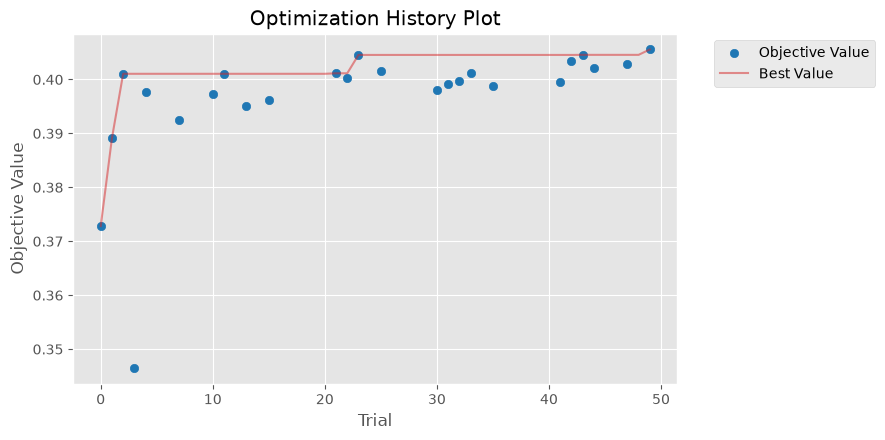

In [9]:
ax = ovm.plot_optimization_history(study)
fig = ax.figure
fig.set_size_inches(9, 4.5)
plt.tight_layout()

with mlflow.start_run(run_id=run_id_best):
    mlflow.log_figure(fig, "optimization_history.png")

plt.show()

### Importance des hyperparamètres

Importance des hyperparamètres (fanova) :
  scale_pos_weight   0.2945
  max_depth          0.2881
  reg_alpha          0.1388
  learning_rate      0.0915
  reg_lambda         0.0776
  colsample_bytree   0.0528
  n_estimators       0.0334
  subsample          0.0148
  min_child_weight   0.0085


C:\Users\Admin\AppData\Local\Temp\ipykernel_22676\3937525897.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = ovm.plot_param_importances(study)


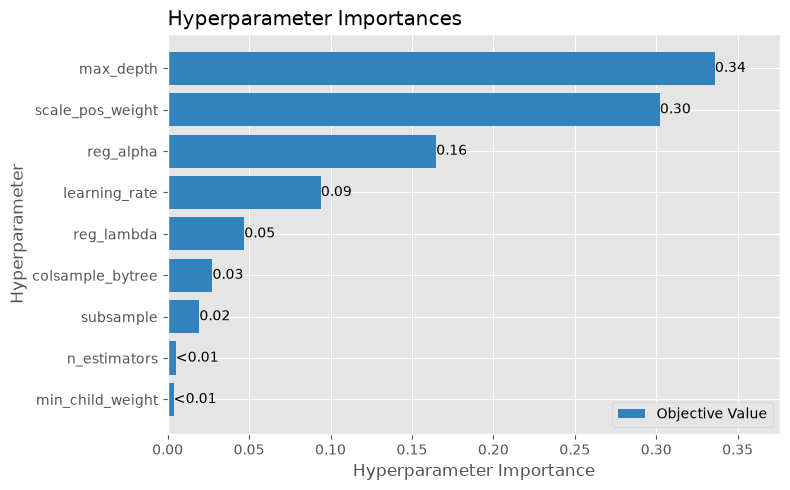

In [10]:
importances = optuna.importance.get_param_importances(study)
print("Importance des hyperparamètres (fanova) :")
for hp, imp in importances.items():
    print(f"  {hp:<18} {imp:.4f}")

ax = ovm.plot_param_importances(study)
fig = ax.figure
fig.set_size_inches(8, 5)
plt.tight_layout()

with mlflow.start_run(run_id=run_id_best):
    mlflow.log_figure(fig, "param_importances.png")

plt.show()

### Slice plot — 2-3 hyperparamètres dominants

Affiche, pour chaque essai, la valeur de l'hyperparamètre en abscisse et la PR-AUC obtenue en ordonnée — permet de voir si une zone de valeurs se démarque clairement, ou si le nuage de points est dispersé sans tendance nette.

Hyperparamètres dominants retenus pour le slice plot : ['scale_pos_weight', 'max_depth', 'reg_alpha']


C:\Users\Admin\AppData\Local\Temp\ipykernel_22676\2345505604.py:4: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  axes = ovm.plot_slice(study, params=top_hps)
C:\Users\Admin\AppData\Local\Temp\ipykernel_22676\2345505604.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


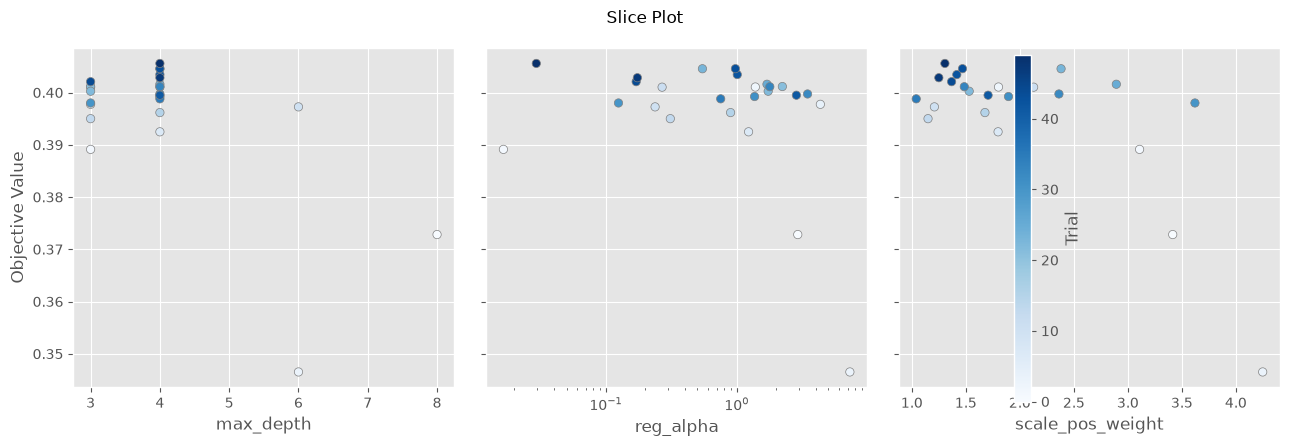

In [11]:
top_hps = list(importances.keys())[:3]
print("Hyperparamètres dominants retenus pour le slice plot :", top_hps)

axes = ovm.plot_slice(study, params=top_hps)
fig = axes[0].figure if hasattr(axes, "__iter__") else axes.figure
fig.set_size_inches(13, 4.5)
plt.tight_layout()

with mlflow.start_run(run_id=run_id_best):
    mlflow.log_figure(fig, "slice_plot_top_hp.png")

plt.show()

### Lecture de la stabilité (variance entre essais proches) et des HP qui comptent vraiment

In [12]:
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
values = np.array([t.value for t in completed_trials])

top10_idx = np.argsort(values)[-10:]
top10_values = values[top10_idx]

print(f"PR-AUC (CV) — meilleurs 10 essais : mean={top10_values.mean():.4f}  std={top10_values.std():.4f}")
print(f"PR-AUC (CV) — tous essais complets : mean={values.mean():.4f}  std={values.std():.4f}  n={len(values)}")
print(f"\nÉcart-type inter-essais (top 10) : {top10_values.std():.4f}")
print(f"Gain vs baseline (étape 5) : {gain_prauc:.4f}")
if top10_values.std() >= abs(gain_prauc):
    print(">> Le gain observé est du même ordre que le bruit d'échantillonnage inter-essais : à interpréter avec prudence.")
else:
    print(">> Le gain observé dépasse la variance inter-essais du top 10 : signal plus probablement réel.")

PR-AUC (CV) — meilleurs 10 essais : mean=0.4028  std=0.0016
PR-AUC (CV) — tous essais complets : mean=0.3965  std=0.0120  n=25

Écart-type inter-essais (top 10) : 0.0016
Gain vs baseline (étape 5) : 0.0175
>> Le gain observé dépasse la variance inter-essais du top 10 : signal plus probablement réel.


**Point d'attention — un écart `val` flatteur mais une importance d'HP erratique = signe de sur-ajustement du tuning**

Si le meilleur essai affiche un gain net sur la validation, mais que :
- l'importance des hyperparamètres (ci-dessus) ne dégage **aucun hyperparamètre clairement dominant** (toutes les importances proches, dispersées, sans structure), et/ou
- les meilleurs essais ne partagent **aucune zone de valeurs commune** dans le slice plot (des optima trouvés à des valeurs très différentes d'un essai à l'autre pour un même hyperparamètre important),

...alors Optuna n'a probablement pas trouvé une vraie zone de bons hyperparamètres, mais a **exploité une combinaison chanceuse sur ce split de validation précis** — l'algorithme de tuning s'est en quelque sorte "sur-ajusté" au bruit d'échantillonnage du split, pas à un signal réel dans les données. C'est un sur-ajustement d'un niveau différent de celui d'un modèle individuel : c'est le **processus de recherche d'hyperparamètres lui-même** qui s'est ajusté à la spécificité d'un split de validation.

**Exemple concret** : imaginons 50 essais où le meilleur obtient PR-AUC=0.42 avec `max_depth=7`, mais où le 2ᵉ meilleur essai (PR-AUC=0.419, quasi identique) a `max_depth=3`, et le 3ᵉ meilleur `max_depth=8` avec un `learning_rate` dix fois plus élevé que les deux autres. Si l'importance de `max_depth` ressort pourtant comme dominante dans le graphique d'importance (parce que fANOVA capte une variance globale sur tout l'espace, y compris les mauvais essais), c'est trompeur : les **meilleurs** essais ne convergent vers aucune valeur commune de `max_depth`, ce qui signale que le gain du meilleur essai est probablement un artefact de ce split de validation précis plutôt qu'un optimum robuste.

**Comment s'en prémunir** :
1. **Ne jamais choisir le meilleur hyperparamètre sur la seule valeur du meilleur essai** — regarder si les 5-10 meilleurs essais convergent vers une zone de valeurs cohérente pour les HP importants (visible sur le slice plot).
2. **Revalider avec plusieurs seeds ou plusieurs splits** (k-fold sur le train, ou plusieurs `TimeSeriesSplit` avec des tailles de fenêtre différentes) avant de figer un choix — un optimum stable doit rester bon sous des variations mineures du protocole.
3. **Se méfier d'un espace de recherche trop large par rapport au nombre d'essais** (cf. étape 4) — plus l'espace est grand, plus il est facile de "trouver" une combinaison qui a l'air bonne juste par hasard (multiple testing implicite : tester 50 combinaisons aléatoires sur un seul split augmente mécaniquement la chance qu'une d'entre elles paraisse excellente sans l'être vraiment).

## 7. Validation finale — pas de sur-ajustement au tuning

Étapes :
1. Réentraîner le modèle avec les meilleurs hyperparamètres sur **train + validation combinés** (toutes les données disponibles avant le test).
2. Évaluer **une seule fois** sur le **test set**, jamais vu ni pendant le tuning (fonction objectif), ni pendant la sélection du meilleur essai (comparaison à la baseline en étape 5).
3. Comparer explicitement au modèle baseline réentraîné de la même façon, pour un chiffre final honnête.

In [13]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

print(f"Train+Validation combinés : {len(X_trainval)} lignes ({y_trainval.mean():.1%} positifs)")

# --- Modèle final : meilleurs hyperparamètres Optuna, réentraîné sur train+val ---
final_model = xgb.XGBClassifier(
    **study.best_params, tree_method="hist", n_jobs=XGB_N_JOBS_SINGLE, eval_metric="aucpr", random_state=SEED,
)
final_model.fit(X_trainval, y_trainval)

test_proba_final = final_model.predict_proba(X_test)[:, 1]
final_prauc_test = average_precision_score(y_test, test_proba_final)
final_auc_test = roc_auc_score(y_test, test_proba_final)

# --- Baseline réentraînée sur train+val, pour une comparaison à armes égales ---
baseline_final_model = xgb.XGBClassifier(
    **BASELINE_PARAMS, tree_method="hist", n_jobs=XGB_N_JOBS_SINGLE, eval_metric="aucpr", random_state=SEED,
)
baseline_final_model.fit(X_trainval, y_trainval)

test_proba_baseline = baseline_final_model.predict_proba(X_test)[:, 1]
baseline_prauc_test = average_precision_score(y_test, test_proba_baseline)
baseline_auc_test = roc_auc_score(y_test, test_proba_baseline)

with mlflow.start_run(run_name="final_evaluation_test_set"):
    mlflow.log_params({**study.best_params, "horizon": HORIZON, "model": "xgboost_optuna_final"})
    mlflow.log_metrics({
        "prauc_test_optuna": final_prauc_test, "auc_test_optuna": final_auc_test,
        "prauc_test_baseline": baseline_prauc_test, "auc_test_baseline": baseline_auc_test,
    })

final_comparison = pd.DataFrame([
    {"modèle": "Baseline (train+val)", "PR-AUC (test)": baseline_prauc_test, "AUC (test)": baseline_auc_test},
    {"modèle": "Optuna best (train+val)", "PR-AUC (test)": final_prauc_test, "AUC (test)": final_auc_test},
])
final_comparison

Train+Validation combinés : 114135 lignes (16.7% positifs)


,modèle,PR-AUC (test),AUC (test)
0,Baseline (train+val),0.438483,0.680999
1,Optuna best (train+val),0.455416,0.693827


In [14]:
gain_test_prauc = final_prauc_test - baseline_prauc_test
gain_test_pct = 100 * gain_test_prauc / baseline_prauc_test

print(f"Gain final PR-AUC (test) : {gain_test_prauc:+.4f}  ({gain_test_pct:+.1f}%)")
print(f"Gain observé en validation (étape 5) : {gain_prauc:+.4f}  ({gain_pct:+.1f}%)")

if abs(gain_test_prauc - gain_prauc) / max(abs(gain_prauc), 1e-6) > 0.5:
    print(">> Écart notable entre le gain validation et le gain test : le gain observé en validation ne se généralise pas complètement — signal de sur-ajustement du tuning à surveiller (cf. étape 6).")
else:
    print(">> Le gain se confirme de façon cohérente entre validation et test : signal plus fiable.")

Gain final PR-AUC (test) : +0.0169  (+3.9%)
Gain observé en validation (étape 5) : +0.0175  (+4.0%)
>> Le gain se confirme de façon cohérente entre validation et test : signal plus fiable.


## 8. Temps de traitement global

In [15]:
_total_elapsed = time.time() - _notebook_start_time
print(f"Temps total d'exécution du notebook : {_total_elapsed:.1f} s  ({_total_elapsed/60:.1f} min)")
print(f"  dont étude Optuna ({N_TRIALS} essais max, {N_SPLITS} folds chacun) : {_study_elapsed:.1f} s ({_study_elapsed/60:.1f} min)")

Temps total d'exécution du notebook : 866.7 s  (14.4 min)
  dont étude Optuna (50 essais max, 3 folds chacun) : 780.9 s (13.0 min)
